
**Time-Domain Analysis**

This section describes the methods used to analyze audio signals in the time domain. The goal is to extract meaningful temporal features that characterize the behavior of speech signals over time and can be used for classification.

1. Audio Loading and Preprocessing

Each audio file is loaded as a time-domain signal along with its sampling rate. The signals are converted to a single channel and normalized to ensure consistency across recordings. All signals are processed at a fixed sampling rate of 8 kHz.

2. Time-Domain Signal Analysis

The time-domain representation provides direct information about how the signal amplitude changes over time. By analyzing this representation, we can study the temporal structure of spoken digits, including their duration, amplitude variation, and regions of activity and silence.

3. Zero-Crossing Rate (ZCR)

The Zero-Crossing Rate measures how frequently the signal changes sign (crosses the zero axis).

Higher ZCR - more rapid changes in the signal, indicating higher-frequency or more complex content

Lower ZCR - smoother signals with fewer rapid transitions

This feature helps capture the level of activity in the signal and can distinguish between different speech patterns.

4. Signal Energy

Signal energy measures the strength or power of the audio signal over time.

High energy - louder or more intense signal

Low energy - weaker or quieter signal

Energy is computed as the average squared amplitude of the signal. It provides a quantitative measure of how much information is present in the signal and reflects differences in loudness and duration among digits.

5. Signal Envelope

The signal envelope represents a smoothed version of the signal amplitude, highlighting the overall shape of the waveform over time.

It is obtained by taking the absolute value of the signal and applying a smoothing operation.

Captures the general trend of amplitude variation
Reduces the effect of rapid oscillations
Highlights regions where speech is present

The envelope provides insight into how the energy of the signal evolves over time and helps analyze the temporal structure of spoken digits.



In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

In [ ]:
# Extracting the dataset
!unzip -q free-spoken-digit-dataset-master.zip

In [ ]:
folder_path = "free-spoken-digit-dataset-master/recordings"

files = sorted(os.listdir(folder_path))

print("Number of files:", len(files))
print("First 10 files:", files[:10])

Number of files: 3000
First 10 files: ['0_george_0.wav', '0_george_1.wav', '0_george_10.wav', '0_george_11.wav', '0_george_12.wav', '0_george_13.wav', '0_george_14.wav', '0_george_15.wav', '0_george_16.wav', '0_george_17.wav']


In [ ]:
import librosa

folder_path = "free-spoken-digit-dataset-master/recordings"

digit_examples = {}

for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith(".wav"):
        digit = int(file_name.split("_")[0])

        if digit not in digit_examples:
            file_path = os.path.join(folder_path, file_name)
            signal, sample_rate = librosa.load(file_path, sr=8000)
            digit_examples[digit] = {
                "file_name": file_name,
                "signal": signal,
                "sample_rate": sample_rate
            }

        if len(digit_examples) == 10:
            break

print("Loaded digits:", sorted(digit_examples.keys()))
print("Number of loaded examples:", len(digit_examples))

Loaded digits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of loaded examples: 10


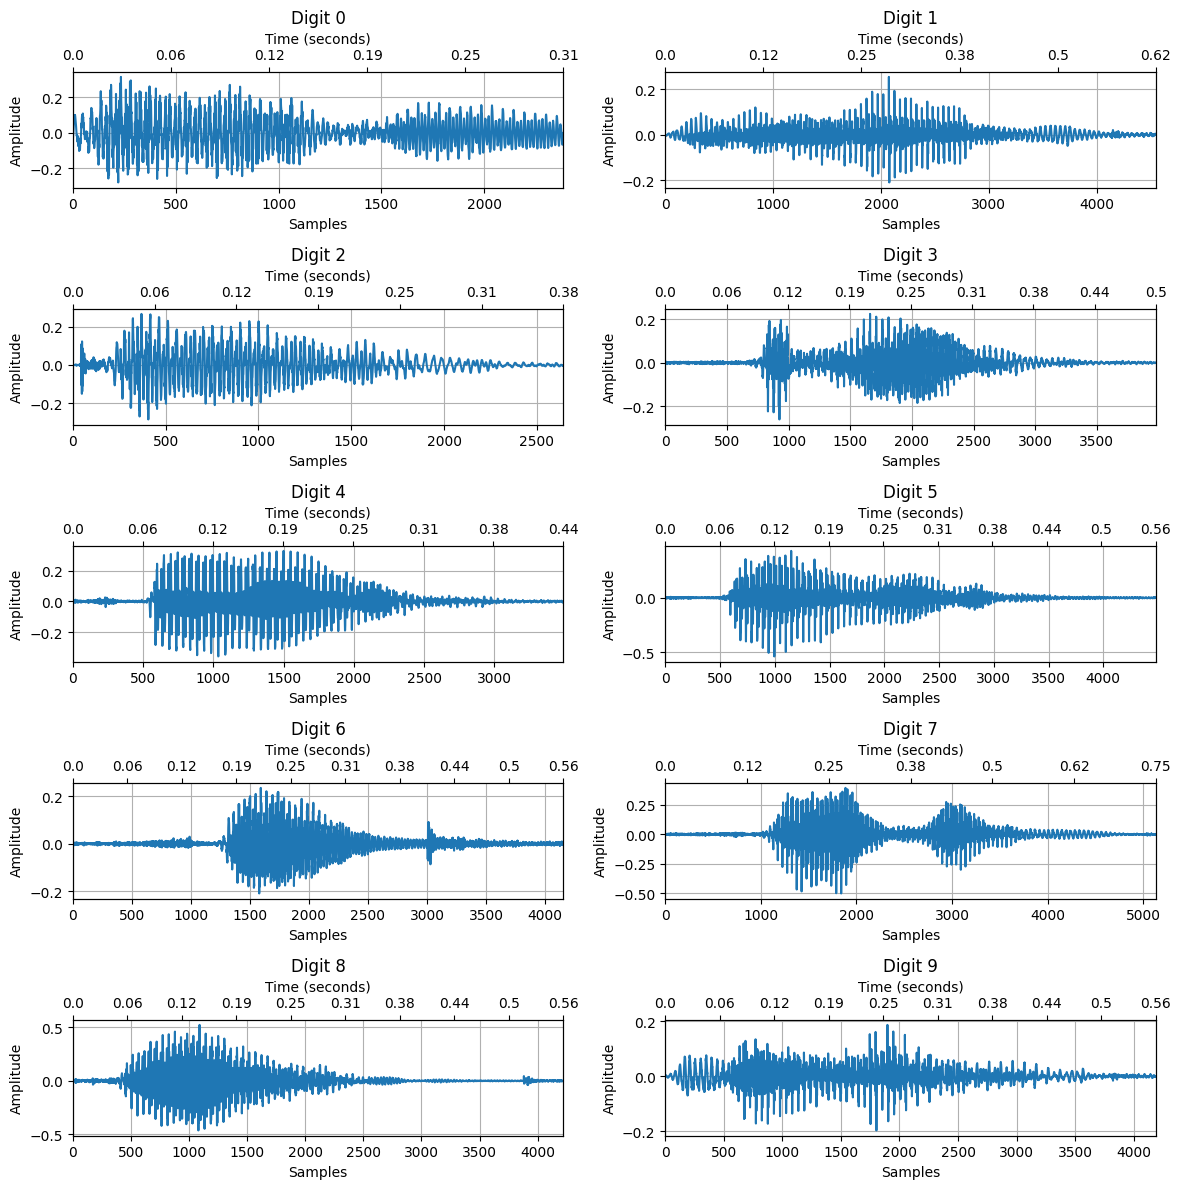

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 2, figsize=(12, 12))
axes = axes.flatten()

for i in range(10):
    signal = digit_examples[i]["signal"]
    sr = digit_examples[i]["sample_rate"]

    samples = np.arange(len(signal))

    ax = axes[i]
    ax.plot(samples, signal)
    ax.set_title(f"Digit {i}")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, len(signal))
    ax.grid()

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())

    ticks = ax.get_xticks()
    ticks = ticks[ticks >= 0]

    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels(np.round(ticks / sr, 2))
    ax_top.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [ ]:
# Zero-Crossing Rate (ZCR):
# Measures how often the signal changes sign (crosses zero).
# High ZCR - more rapid changes (noisy or high-frequency content)
# Low ZCR - smoother signal



def zero_crossing_rate(signal):
    return np.mean(np.abs(np.diff(np.sign(signal))))

folder_path = "free-spoken-digit-dataset-master/recordings"

rows = []

for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith(".wav"):

        file_path = os.path.join(folder_path, file_name)
        signal, sample_rate = librosa.load(file_path, sr=8000)

        digit = int(file_name.split("_")[0])

        zcr = zero_crossing_rate(signal)

        rows.append({
            "file_name": file_name,
            "digit": digit,
            "sample_rate": sample_rate,
            "signal_length": len(signal),
            "zcr": zcr
        })

df_features = pd.DataFrame(rows)

print(df_features.head())
print("Number of files:", len(df_features))

         file_name  digit  sample_rate  signal_length       zcr
0   0_george_0.wav      0         8000           2384  0.319765
1   0_george_1.wav      0         8000           4727  0.247990
2  0_george_10.wav      0         8000           5958  0.413295
3  0_george_11.wav      0         8000           3661  0.327869
4  0_george_12.wav      0         8000           4050  0.317115
Number of files: 3000


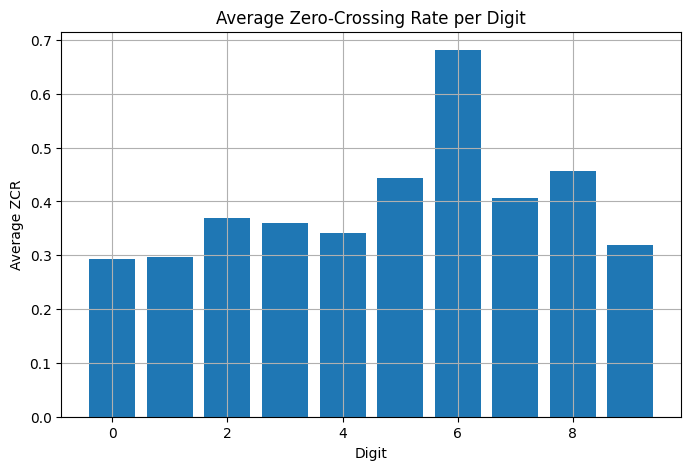

In [ ]:
import matplotlib.pyplot as plt

zcr_mean = df_features.groupby("digit")["zcr"].mean()

plt.figure(figsize=(8,5))
plt.bar(zcr_mean.index, zcr_mean.values)
plt.xlabel("Digit")
plt.ylabel("Average ZCR")
plt.title("Average Zero-Crossing Rate per Digit")
plt.grid()
plt.show()

In [ ]:
# Energy:
# Measures the strength (power) of the signal.
# High energy - loud signal
# Low energy - weak/silent signal

def signal_energy(signal):
    return np.sum(signal ** 2) / len(signal)


energy_values = []

for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith(".wav"):

        file_path = os.path.join(folder_path, file_name)
        signal, sample_rate = librosa.load(file_path, sr=8000)

        energy = signal_energy(signal)
        energy_values.append(energy)

# Adding to existing dataframe
df_features["energy"] = energy_values

print(df_features.head())

         file_name  digit  sample_rate  signal_length       zcr    energy
0   0_george_0.wav      0         8000           2384  0.319765  0.007898
1   0_george_1.wav      0         8000           4727  0.247990  0.002503
2  0_george_10.wav      0         8000           5958  0.413295  0.001995
3  0_george_11.wav      0         8000           3661  0.327869  0.002237
4  0_george_12.wav      0         8000           4050  0.317115  0.002161


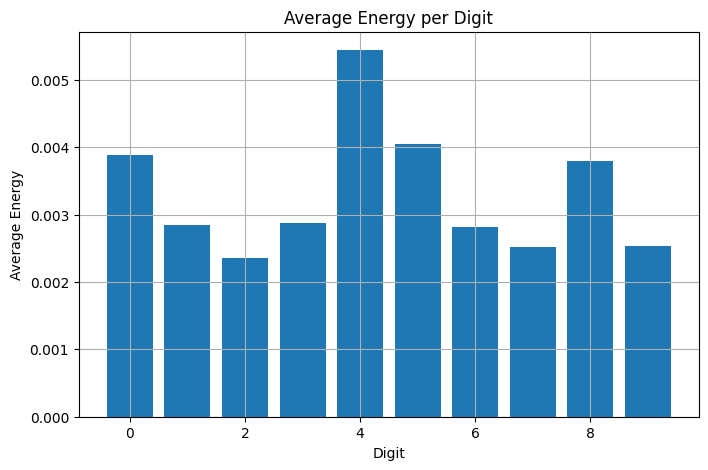

In [ ]:
import matplotlib.pyplot as plt

energy_mean = df_features.groupby("digit")["energy"].mean()

plt.figure(figsize=(8,5))
plt.bar(energy_mean.index, energy_mean.values)
plt.xlabel("Digit")
plt.ylabel("Average Energy")
plt.title("Average Energy per Digit")
plt.grid()
plt.show()

In [ ]:
# Envelope:
# Represents the smooth amplitude variation of the signal over time

def signal_envelope(signal, window_size=200):
    envelope = np.convolve(np.abs(signal), np.ones(window_size)/window_size, mode='same')
    return envelope

envelope_mean_values = []

for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith(".wav"):

        file_path = os.path.join(folder_path, file_name)
        signal, sample_rate = librosa.load(file_path, sr=8000)

        envelope = signal_envelope(signal)
        envelope_mean = np.mean(envelope)

        envelope_mean_values.append(envelope_mean)

# Add to dataframe
df_features["envelope_mean"] = envelope_mean_values

print(df_features.head())

         file_name  digit  sample_rate  signal_length       zcr    energy  \
0   0_george_0.wav      0         8000           2384  0.319765  0.007898   
1   0_george_1.wav      0         8000           4727  0.247990  0.002503   
2  0_george_10.wav      0         8000           5958  0.413295  0.001995   
3  0_george_11.wav      0         8000           3661  0.327869  0.002237   
4  0_george_12.wav      0         8000           4050  0.317115  0.002161   

   envelope_mean  
0       0.069185  
1       0.034413  
2       0.024796  
3       0.032131  
4       0.032191  


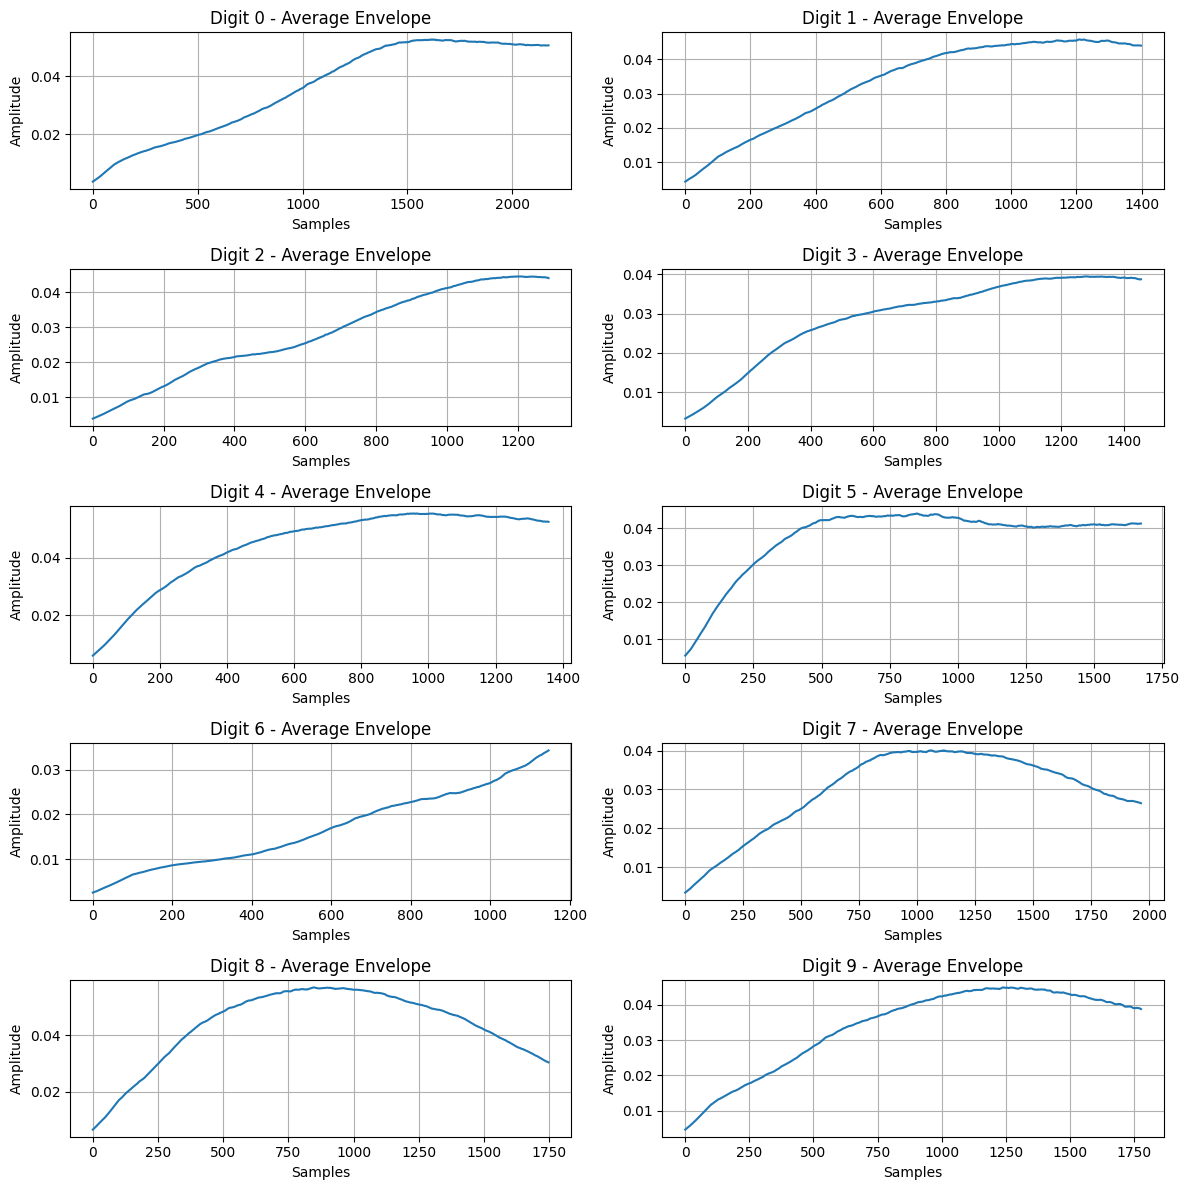

In [ ]:

def signal_envelope(signal, window_size=200):
    return np.convolve(np.abs(signal), np.ones(window_size)/window_size, mode='same')

digit_envelopes = {i: [] for i in range(10)}

for file_name in sorted(os.listdir(folder_path)):
    if file_name.endswith(".wav"):
        digit = int(file_name.split("_")[0])

        signal, sr = librosa.load(os.path.join(folder_path, file_name), sr=8000)
        env = signal_envelope(signal)

        digit_envelopes[digit].append(env)

fig, axes = plt.subplots(5, 2, figsize=(12, 12))
axes = axes.flatten()

for i in range(10):
    env_list = digit_envelopes[i]

    min_len = min(len(e) for e in env_list)
    env_aligned = np.array([e[:min_len] for e in env_list])

    avg_env = np.mean(env_aligned, axis=0)

    axes[i].plot(avg_env)
    axes[i].set_title(f"Digit {i} - Average Envelope")
    axes[i].set_xlabel("Samples")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid()

plt.tight_layout()
plt.show()

In [ ]:
df_features.to_csv("member1_time_domain_features.csv", index=False)
print(os.listdir())

['.config', 'free-spoken-digit-dataset-master', 'member1_time_domain_features.csv', 'free-spoken-digit-dataset-master.zip', 'sample_data']
